# Project 01 - Predicting Customer Churn (Classical Machine Learning)

**A self-explanatory Kaggle notebook.** Every code cell has a short plain-English
explanation right above it. Just press **Run All** and read top to bottom.

**What you'll learn**
- What *supervised learning* and *classification* actually mean.
- How to split data correctly and why *data leakage* ruins models.
- How to compare models with *cross-validation* and judge them with the *right metric* (AUC).
- How to read a *confusion matrix* and an *ROC curve*.

**Topic map:** this is the entry point to classical ML - the kind of tabular prediction that
still runs most of the business world (churn, fraud, pricing, demand).

## The scenario

You work at a telecom company. Every month some customers **leave** (this is called *churn*),
and winning a new customer costs far more than keeping an old one. Your boss asks:

> "Can you tell me *which* customers are about to leave, so we can offer them a deal first?"

That is a **prediction** problem. For each customer we want to output a number between 0 and 1:
the **probability they will churn**. Predicting a Yes/No label like this is called **binary
classification**.

## Foundations (the words you need, in plain English)

- **Supervised learning** = learning from examples where we already know the answer. We show
  the computer thousands of past customers labelled "churned" or "stayed", and it learns the
  pattern.
- **Features (X)** = the input facts about each customer (tenure, monthly bill, contract type).
- **Target (y)** = the thing we predict (did they churn: 1 = yes, 0 = no).
- **Model** = the learned function that maps features -> a churn probability.

Analogy: it's like a doctor learning from many past patients (symptoms -> diagnosis), then
diagnosing a new patient from their symptoms.

### Cell 1 - import our tools
We load NumPy/pandas (for data), scikit-learn (the ML toolkit), and matplotlib (for diagrams).
`%matplotlib inline` tells the notebook to draw charts right here under the cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

print("tools ready")

tools ready


### Cell 2 - make a dataset (so this notebook runs anywhere)
For learning, we generate **synthetic** customers with a *known* churn pattern baked in
(month-to-month contracts, high bills, low tenure -> more churn). Because we built the
pattern, we know a good model should find it. **For the real project**, replace this with the
Kaggle "Telco Customer Churn" CSV - the rest of the notebook stays the same.

In [2]:
def make_demo_data(n=2000, seed=42):
    rng = np.random.default_rng(seed)
    tenure = rng.integers(0, 72, n)                 # months as a customer
    monthly = rng.normal(70, 30, n).clip(15, 130)   # monthly bill
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[.55,.25,.20])
    internet = rng.choice(["Fiber optic", "DSL", "No"], n, p=[.45,.35,.20])
    # build a realistic signal, then add noise
    logit = (-2.0 + 1.4*(contract=="Month-to-month") + 0.015*monthly
             - 0.04*tenure + 0.6*(internet=="Fiber optic") + rng.normal(0,0.5,n))
    churn = (1/(1+np.exp(-logit)) > rng.random(n)).astype(int)
    return pd.DataFrame({"tenure": tenure, "MonthlyCharges": monthly.round(2),
                         "TotalCharges": (tenure*monthly).round(2),
                         "Contract": contract, "InternetService": internet,
                         "Churn": np.where(churn==1, "Yes", "No")})

df = make_demo_data()
df.head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
0,6,47.73,286.41,One year,Fiber optic,Yes
1,55,97.73,5375.19,One year,No,No
2,47,71.04,3338.80,Month-to-month,Fiber optic,No
3,31,61.52,1907.00,Month-to-month,No,No
4,31,66.81,2071.25,One year,DSL,No


### Cell 3 - first look at the data
Always *look* before modelling. We check the size, the share of customers who churned (the
**class balance**), and basic statistics. Here ~27% churn - that imbalance is why we won't
trust plain accuracy later.

In [3]:
print("rows, columns:", df.shape)
print("\nchurn rate:")
print(df["Churn"].value_counts(normalize=True).round(3))
df.describe()

rows, columns: (2000, 6)

churn rate:
Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64


,tenure,MonthlyCharges,TotalCharges
count,2000.000000,2000.000000,2000.000000
mean,35.497000,69.408320,2474.291745
std,20.884565,28.764557,1869.656333
min,0.000000,15.000000,0.000000
25%,17.000000,49.170000,893.930000
50%,36.000000,70.090000,2103.230000
75%,54.000000,89.550000,3719.242500
max,71.000000,130.000000,8970.000000


### Cell 4 - diagram: how many customers churn?
A quick bar chart of churn vs stay. Notice the bars are uneven (imbalanced). With imbalance, a
lazy model that always predicts "stay" would look ~73% accurate while being useless - which is
exactly why we'll use **AUC** instead of accuracy.

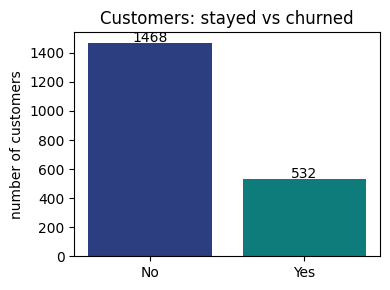

In [4]:
counts = df["Churn"].value_counts()
plt.figure(figsize=(4,3))
plt.bar(counts.index, counts.values, color=["#2d3e80", "#0e7c7b"])
plt.title("Customers: stayed vs churned")
plt.ylabel("number of customers")
for i, v in enumerate(counts.values):
    plt.text(i, v+10, str(v), ha="center")
plt.tight_layout(); plt.show()

## Why we split data into train and test
If we test a model on the same rows it studied, it can just *memorise* them and look perfect.
So we hide a **test set** it never sees during training. Its score there estimates real-world
performance. The test set is the **final exam** - we look at it exactly once, at the end.
`stratify=y` keeps the churn rate the same in train and test so the exam is fair.

### Cell 5 - separate inputs (X) from the answer (y), then split

In [5]:
y = (df["Churn"] == "Yes").astype(int)     # convert Yes/No to 1/0
X = df.drop(columns=["Churn"])
num_cols = X.select_dtypes(include="number").columns.tolist()   # numeric features
cat_cols = X.select_dtypes(exclude="number").columns.tolist()   # text/category features

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          stratify=y, random_state=42)
print("train rows:", len(X_tr), "| test rows:", len(X_te))
print("numeric:", num_cols)
print("categorical:", cat_cols)

train rows: 1600 | test rows: 400
numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical: ['Contract', 'InternetService']


## Leakage and the Pipeline (the #1 professional habit)
**Data leakage** is when information you wouldn't have at prediction time sneaks into training -
for example, scaling using statistics from the *whole* dataset (including the test rows). The
score looks amazing, then collapses in production.

**The fix:** put all preprocessing *inside* one `Pipeline` object. During cross-validation it
is re-fit on each training fold only, so test information can never leak in.

### Cell 6 - build a leakage-safe pipeline
Numeric branch = fill missing + scale. Categorical branch = fill missing + one-hot encode.
`handle_unknown='ignore'` means a category we never saw in training won't crash at serve time.

In [6]:
def build_pipeline(num, cat, model):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("pre", pre), ("model", model)])

print("pipeline factory ready")

pipeline factory ready


## Baselines + a real model
A score means nothing without a reference. We compare three models, each wrapped in the same
leakage-safe pipeline:
- **Dummy** (always predict the common class) - the floor (AUC ~0.50).
- **Logistic regression** - a strong, simple linear bar.
- **Gradient boosting** (HistGBM) - trees that fix each other's mistakes; usually the winner.

### Cell 7 - compare models with cross-validation
**Cross-validation** rotates the validation slice over 5 folds and averages, giving a steadier
score than a single split. We do this on the **training** data only - the test set stays sealed.

In [7]:
candidates = {
    "dummy_majority": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=1000),
    "hist_gbm": HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=400),
}
cv_scores = {}
for name, model in candidates.items():
    pipe = build_pipeline(num_cols, cat_cols, model)
    auc = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="roc_auc")
    cv_scores[name] = auc.mean()
    print(f"{name:22s} CV AUC = {auc.mean():.3f} +/- {auc.std():.3f}")

dummy_majority         CV AUC = 0.500 +/- 0.000
logistic_regression    CV AUC = 0.757 +/- 0.029


hist_gbm               CV AUC = 0.711 +/- 0.030


### Cell 8 - train the winner and test it ONCE
We pick the best model by CV, refit it on all training data, then score the sealed test set a
single time. `predict_proba(...)[:,1]` gives the churn *probability* (needed for AUC).

In [8]:
best_name = max(cv_scores, key=cv_scores.get)
print("best by cross-validation:", best_name)
best = build_pipeline(num_cols, cat_cols, candidates[best_name])
best.fit(X_tr, y_tr)

proba = best.predict_proba(X_te)[:, 1]
pred = (proba > 0.5).astype(int)
print(f"\nTEST AUC = {roc_auc_score(y_te, proba):.3f}\n")
print(classification_report(y_te, pred, digits=3))

best by cross-validation: logistic_regression

TEST AUC = 0.785

              precision    recall  f1-score   support

           0      0.793     0.925     0.854       294
           1      0.614     0.330     0.429       106

    accuracy                          0.767       400
   macro avg      0.704     0.628     0.642       400
weighted avg      0.746     0.767     0.741       400



### Cell 9 - diagram: the confusion matrix
This 2x2 grid shows where we were right and wrong. Top-left/bottom-right = correct; the
off-diagonal = mistakes. "False negatives" (we predicted *stay* but they churned) are the
expensive ones for the business.

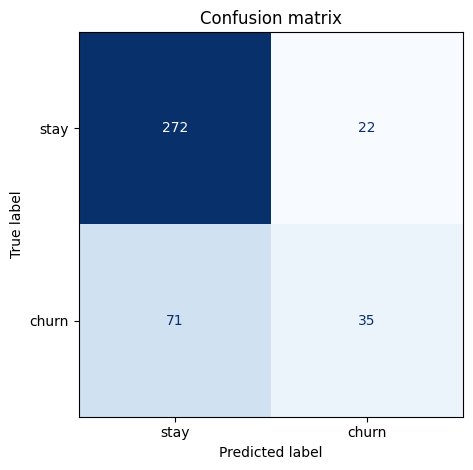

In [9]:
ConfusionMatrixDisplay.from_predictions(y_te, pred, display_labels=["stay","churn"],
                                        cmap="Blues", colorbar=False)
plt.title("Confusion matrix"); plt.tight_layout(); plt.show()

### Cell 10 - diagram: the ROC curve
The ROC curve shows the trade-off between catching churners (true positives) and false alarms,
across every threshold. The area under it = **AUC**. A diagonal line = random guessing (0.5);
the further toward the top-left, the better.

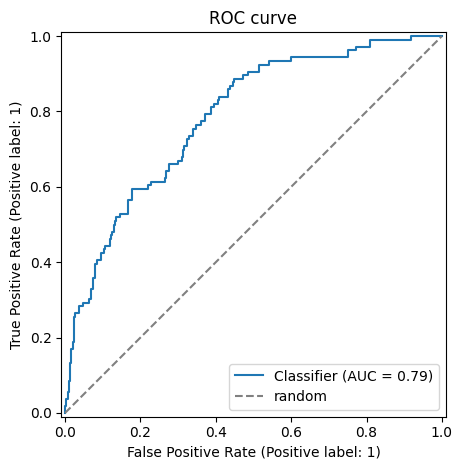

In [10]:
RocCurveDisplay.from_predictions(y_te, proba)
plt.plot([0,1],[0,1],"--", color="grey", label="random")
plt.title("ROC curve"); plt.legend(); plt.tight_layout(); plt.show()

## What just happened (recap)
1. We framed churn as **binary classification**.
2. We **split** data and sealed a test set (no peeking).
3. We built a **leakage-safe pipeline** (preprocessing lives inside it).
4. We **cross-validated** baselines + gradient boosting and picked the best.
5. We scored the test set **once** and read the **AUC**, **confusion matrix**, and **ROC curve**.

This exact shape - *data -> split -> candidates -> validate -> test once -> read metrics* - is
reused in almost every machine-learning project you'll ever build.

## Scenarios & your turn
- **Severe imbalance (2% churn):** accuracy becomes useless; rely on AUC / precision-recall and
  consider class weights. Try changing the churn rate in `make_demo_data`.
- **Pick a threshold:** the business may want to catch 80% of churners even at more false alarms.
  Lower the 0.5 cut-off and watch recall rise.
- **Add a feature:** create `charges_per_tenure = TotalCharges/(tenure+1)` and re-run - does AUC
  improve? (That's the bridge to Project 02: *feature engineering*.)
- **Go real:** download Kaggle's `blastchar/telco-customer-churn` and replace `make_demo_data`.

## Mini-glossary
**feature/target** inputs vs the thing predicted - **classification** predicting a category -
**train/test split** study vs final-exam data - **leakage** test info sneaking into training -
**cross-validation** averaging over 5 folds - **AUC** ranking quality, 0.5=random, 1=perfect -
**confusion matrix** right/wrong counts by class - **ROC curve** true-positive vs false-positive
trade-off.

Next: **Project 02 - Feature Engineering & Data-Centric AI**, where better *data* beats a
fancier model.